# First case

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:

df = pd.read_csv("data/house-prices/train.csv", index_col=0)
df.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1459 entries, 1461 to 2919
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   MSZoning       1455 non-null   object 
 2   LotFrontage    1232 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   Street         1459 non-null   object 
 5   Alley          107 non-null    object 
 6   LotShape       1459 non-null   object 
 7   LandContour    1459 non-null   object 
 8   Utilities      1457 non-null   object 
 9   LotConfig      1459 non-null   object 
 10  LandSlope      1459 non-null   object 
 11  Neighborhood   1459 non-null   object 
 12  Condition1     1459 non-null   object 
 13  Condition2     1459 non-null   object 
 14  BldgType       1459 non-null   object 
 15  HouseStyle     1459 non-null   object 
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearBuilt 

In [59]:
df.describe().drop("count", axis=0)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
mean,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,52.619342,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,176.753926,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,0.000000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,0.000000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,1526.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


<Figure size 900x800 with 0 Axes>

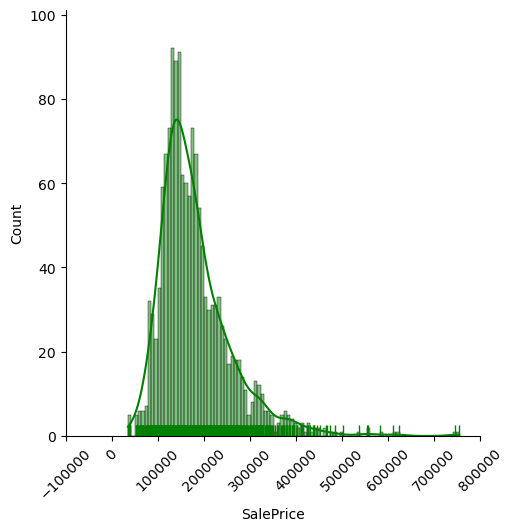

In [78]:
plt.figure(figsize=(9, 8))
g = sns.displot(df["SalePrice"],color='g',rug=True,kde=True, bins=100)
g.set_xticklabels(rotation=45)

In [80]:
numeric_columns = df.select_dtypes(include=["number"]).columns
numeric_columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

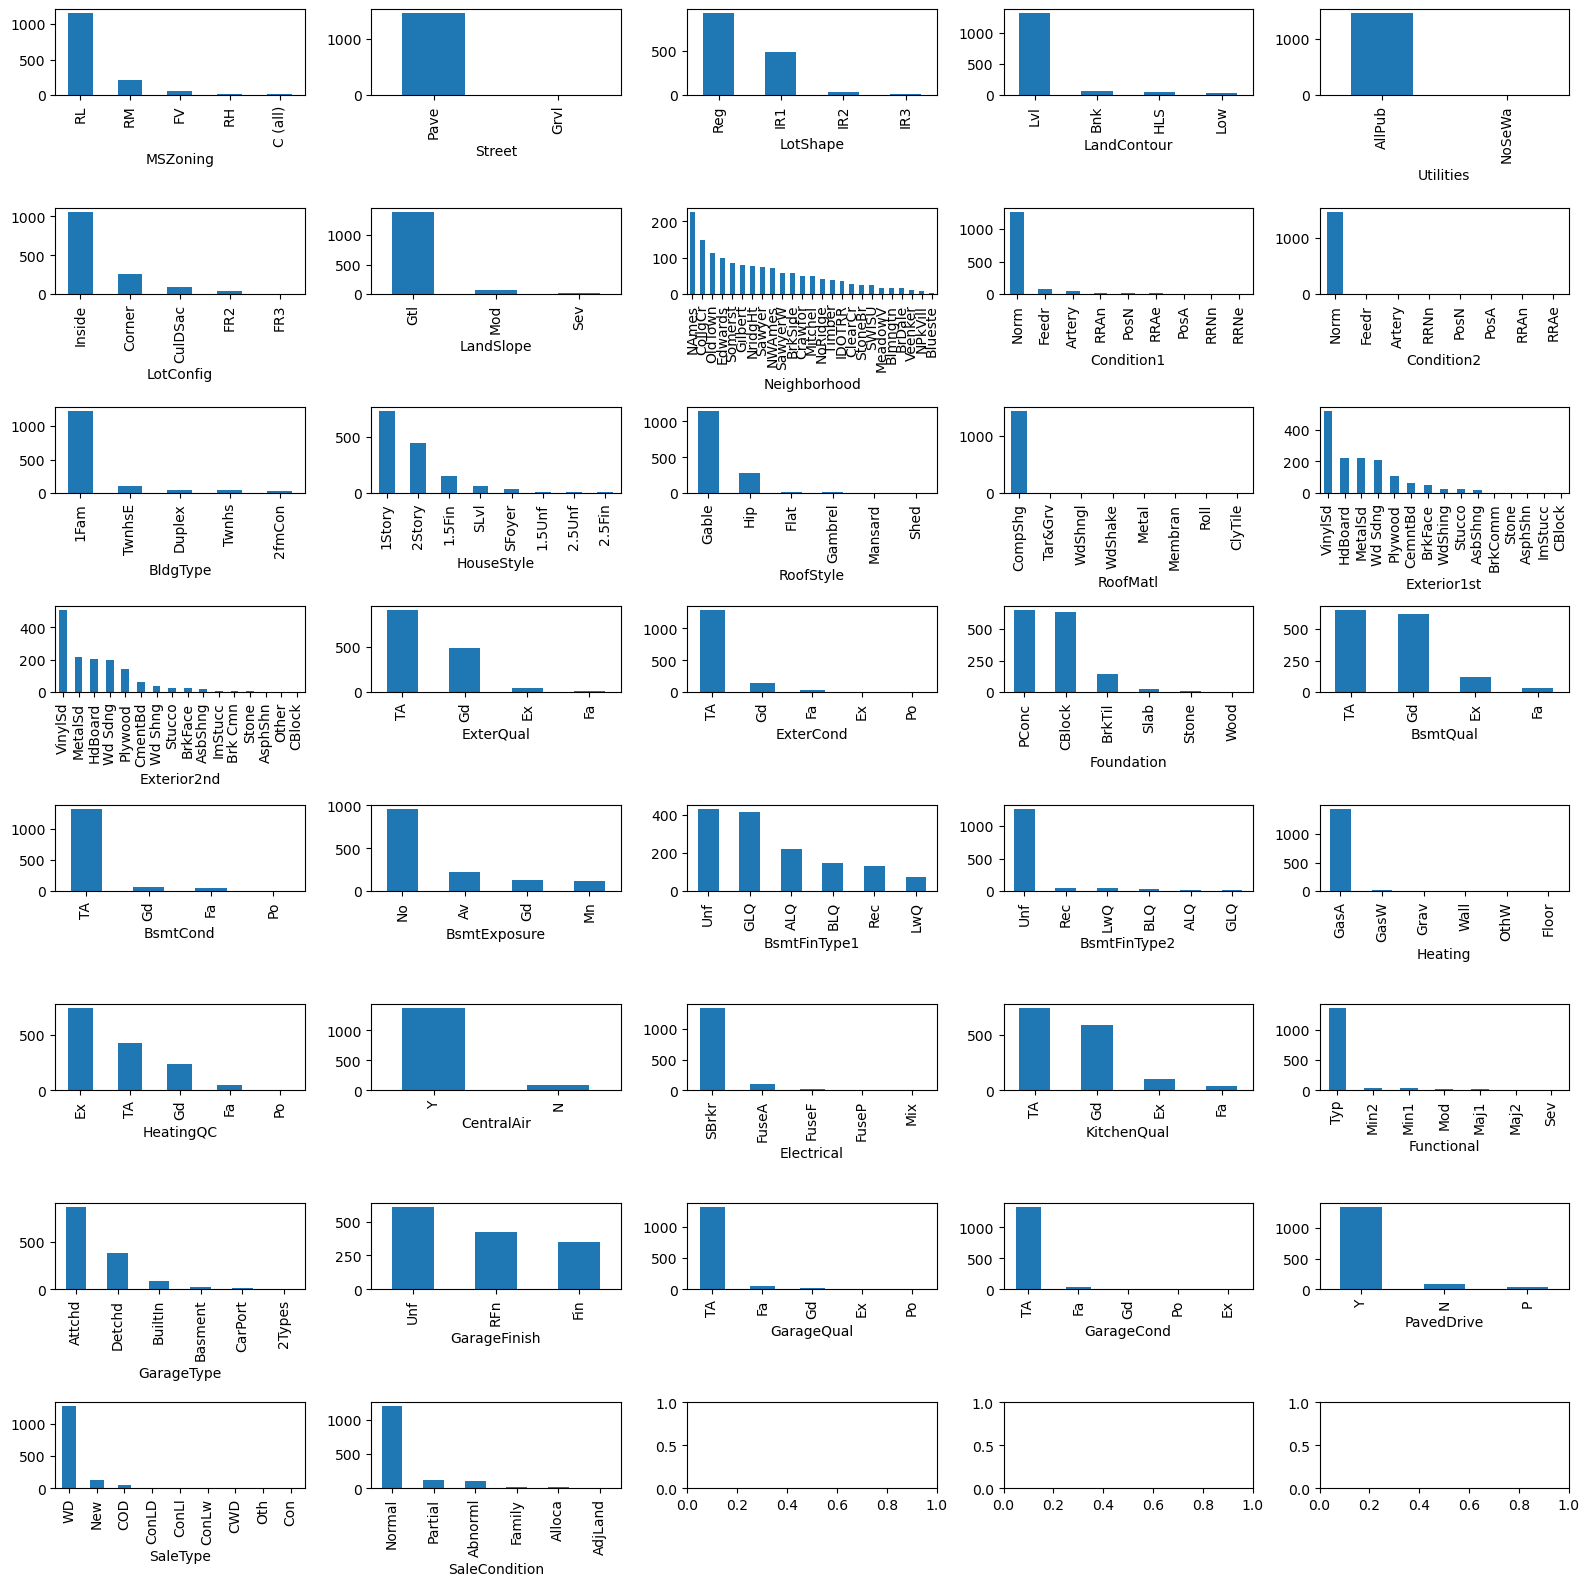

In [112]:
df_cat_desc = df.select_dtypes(exclude=["number"]).describe().T
cat_cols = df_cat_desc[df_cat_desc["count"]>1000].index
ncols = 5
nrows= len(cat_cols)//5 + 1

fig, axes = plt.subplots(nrows=nrows,ncols=ncols, figsize=(16,16))
axxx = axes.flatten() 

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind="bar",ax=axxx[i])
plt.tight_layout()

In [93]:
df.select_dtypes(exclude=["number"]).columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

<Figure size 1600x1600 with 0 Axes>

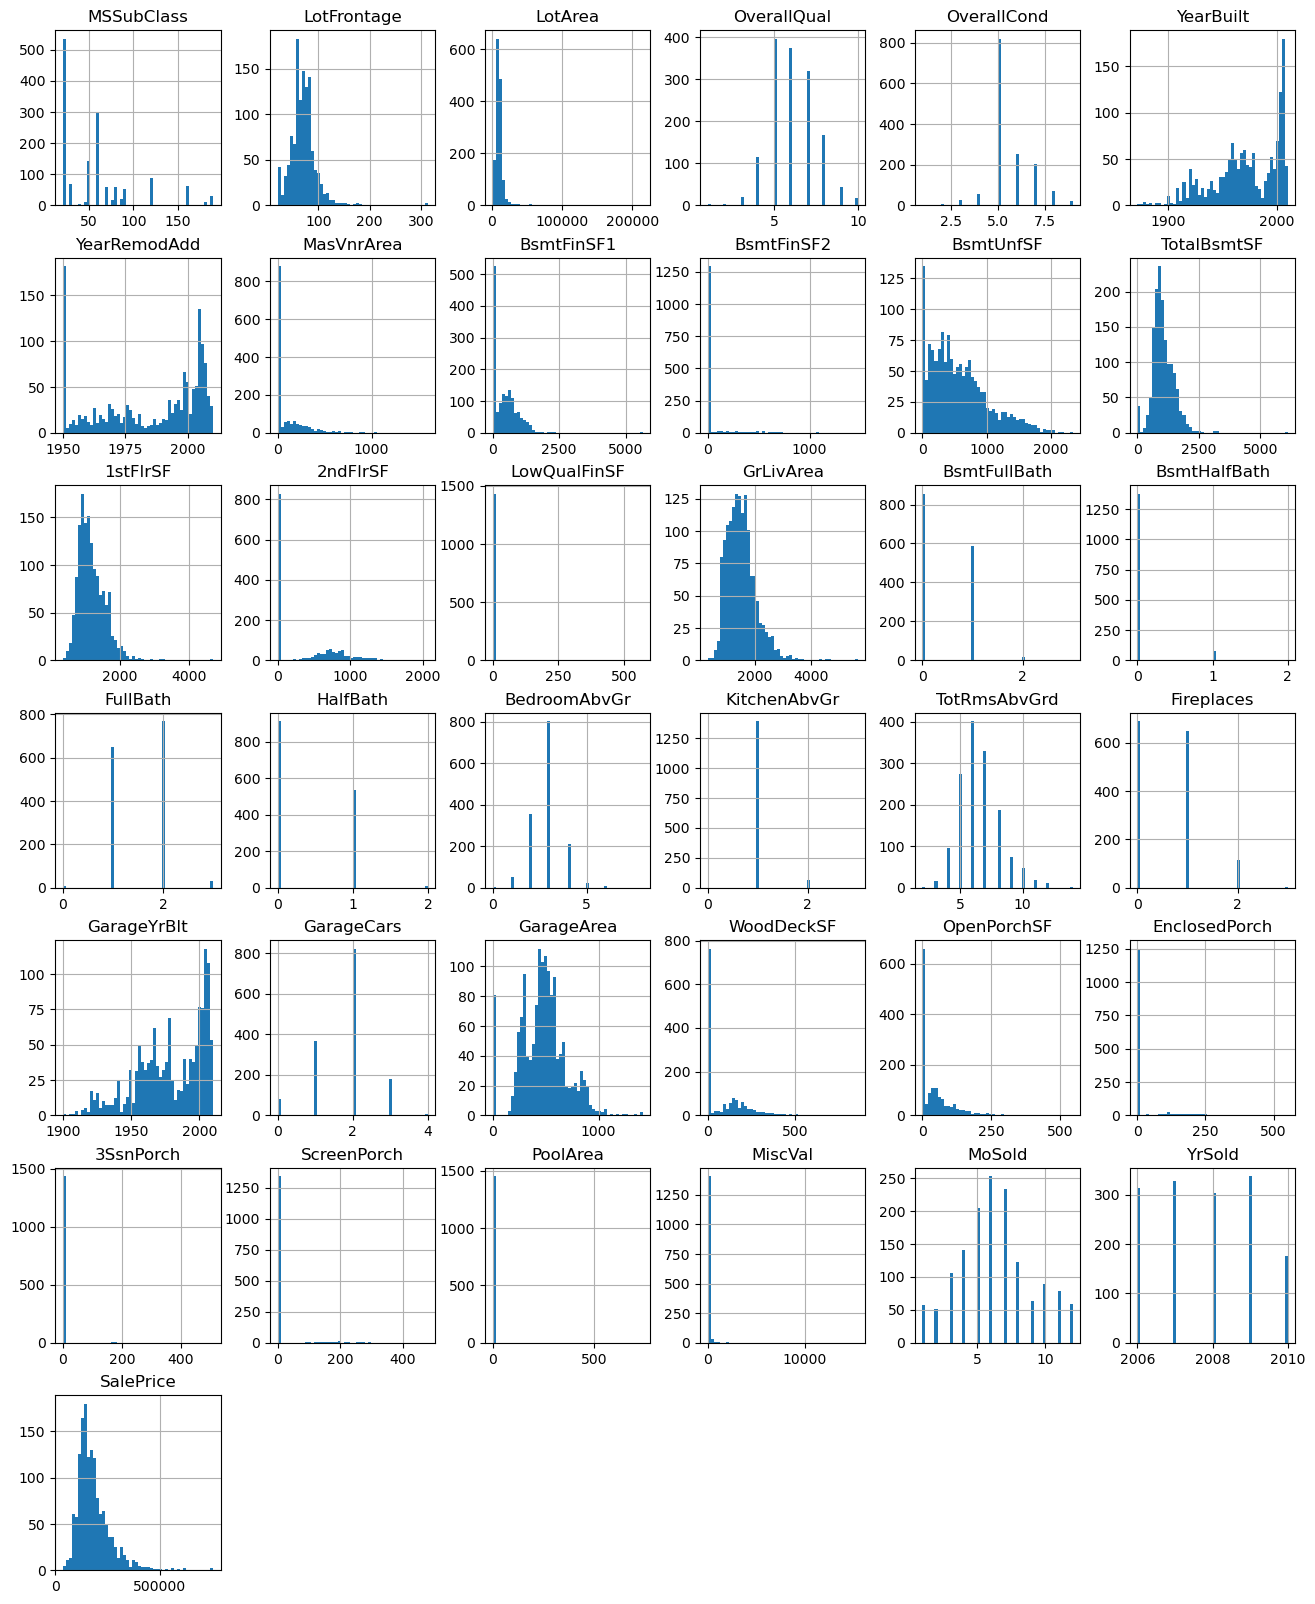

In [85]:
plt.figure(figsize=(16,16))
g=df[numeric_columns].hist(figsize=(16, 20), bins=50)

<Axes: >

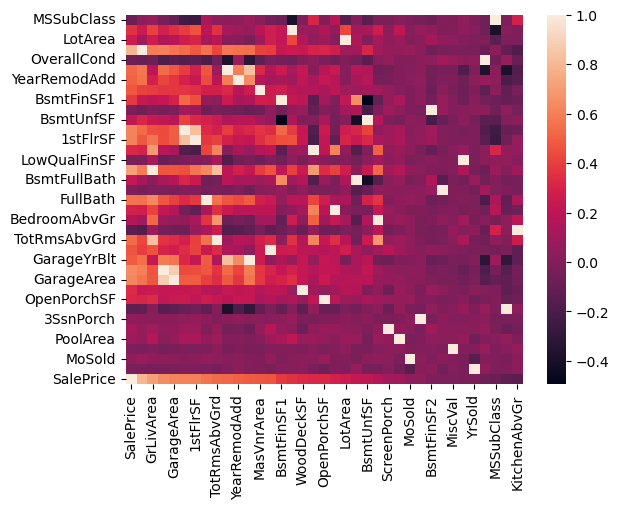

In [92]:
sns.heatmap(df[numeric_columns].corr().sort_values("SalePrice", ascending=False).T)

# Preprocessing and Modeling 

In [1]:
from xgboost import XGBRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import TargetEncoder, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error
from category_encoders import TargetEncoder
import mlflow
from mlflow.tracking import MlflowClient






In [2]:
mlflow.set_tracking_uri("http://localhost:5020")
mlflow.set_experiment("house_price_prediction")
# mlflow.set_registry_uri("sqlite:///mlflow_registry.db")


<Experiment: artifact_location='mlflow-artifacts:/674847845808548485', creation_time=1757426032203, experiment_id='674847845808548485', last_update_time=1757426032203, lifecycle_stage='active', name='house_price_prediction', tags={}>

In [4]:
mlflow.start_run(run_name="xgboost_model_run_1")


<ActiveRun: >

In [9]:
target = "SalePrice"
x_train, x_valid,y_train,y_valid = train_test_split(df.drop(target, axis=1), df[target], test_size=0.1, random_state=42)

numeric_columns = x_train.select_dtypes(include=["number"]).columns
categorical_columns = x_train.select_dtypes(exclude=["number"]).columns
for col in categorical_columns:
    x_train[col] = x_train[col].astype("category")

num_proc = Pipeline(
    [
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)
nom_proc = Pipeline(
    [("imp", SimpleImputer(strategy="most_frequent")), ("encoder", TargetEncoder())]
)


pre = ColumnTransformer(
    [("num", num_proc, numeric_columns), ("cat", nom_proc, categorical_columns)],
    remainder="drop",
)
# x = pre.fit_transform(x_train, y_train)


pipe = Pipeline(
    [
        ("pre", pre),
        (
            "xgb_model",
            XGBRegressor(
                enable_categorical=True,
                objective="reg:squarederror",
            ),
        ),
    ]
)

In [10]:
pipe.fit(x_train,y_train)

,steps,"[('pre', ...), ('xgb_model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
mlflow.sklearn.log_model(pipe)

2025/09/09 08:33:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [3]:
client = MlflowClient()
experiments = client.search_experiments(view_type=mlflow.entities.ViewType.ALL)
for exp in experiments:
    print(f"Name: {exp.name}, Experiment ID: {exp.experiment_id}")


Name: house_price_prediction, Experiment ID: 674847845808548485
Name: Boston Model Experiment, Experiment ID: 417350048653659120
Name: Default, Experiment ID: 0


In [3]:
runs_df = mlflow.search_runs(experiment_names=["house_price_prediction"])
last_run = mlflow.search_runs(
    experiment_names=["house_price_prediction"],
    max_results=1,
    order_by=["attributes.start_time DESC"]
)
last_run

,run_id,experiment_id,status,artifact_uri,start_time,end_time,tags.mlflow.runName,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.source.type
0,1fbc7a2455154502a8c22d7013cda6b1,674847845808548485,RUNNING,mlflow-artifacts:/674847845808548485/1fbc7a245...,2025-09-09 15:32:53.839000+00:00,None,xgboost_model_run_1,c:\ProgramData\anaconda3\Lib\site-packages\ipy...,mamma,LOCAL


In [ ]:
downloaded_path = mlflow.artifacts.download_artifacts(
    run_id=last_run['run_id'][0],
    artifact_path="model"
)


In [ ]:
df.apply(lambda x: [1, 2], axis=1), df.apply(lambda x: [1, 2], axis=1,result_type='expand'), df.apply(lambda x: [1, 2], axis=0)

(0    [1, 2]
 1    [1, 2]
 2    [1, 2]
 3    [1, 2]
 dtype: object,
    0  1
 0  1  2
 1  1  2
 2  1  2
 3  1  2,
    category  value  category_mapped  value_doubled
 0         1      1                1              1
 1         2      2                2              2)

In [ ]:
model = mlflow.sklearn.load_model(f"runs:/{mlflow.active_run().info.run_id}/xgboost_model_run_1")

In [ ]:
preds = pipe.predict(x_valid)


array([143668.67 , 324318.88 , 102016.65 , 147413.92 , 290897.62 ,
        77341.91 , 216976.03 , 148558.03 ,  76503.32 , 143721.69 ,
       144028.38 , 129785.38 , 105953.055, 223008.4  , 173010.64 ,
       128632.016, 191179.72 , 125707.914, 108183.75 , 193157.38 ,
       141691.25 , 225197.06 , 177368.2  , 125804.48 , 195208.11 ,
       169267.95 , 191139.95 , 117458.38 , 174889.19 , 216880.39 ,
       113182.76 , 266976.06 , 217546.11 , 126104.195, 252738.5  ,
       153083.44 , 116544.375, 208136.56 , 324147.1  , 114267.36 ,
       122369.445, 229900.89 , 125555.64 , 406407.8  , 111845.086,
       119308.11 , 117303.9  , 130401.69 , 440996.72 , 131257.25 ,
       129703.66 , 188551.5  , 103494.88 , 310791.56 , 141748.3  ,
       258715.77 , 197409.75 , 146433.92 , 144323.4  , 101192.4  ,
        69794.37 , 155659.06 , 308075.22 , 261078.3  , 282744.5  ,
       229801.73 , 118932.66 , 331693.03 , 121729.89 , 176762.56 ,
       125963.97 , 132828.05 , 121516.51 ,  83529.12 , 456127.

select TO_CHAR(rental_date, 'YYYYY-MM'), customer_id from rental limit 25

select extract(month  from rental_date)

build feature pipelines as explicit fit/transform chains to prevent leakage, fit transformations only on the training set, and use time-aware splits like rolling-origin for time series.</br> also encapsulate custom transformers in sklearn-style classes, persist the whole pipeline, and enforce schema validation in production.”

In [6]:
import psycopg2
import pandas as pd


conn = psycopg2.connect(
    host="localhost", database="dvdrental", user="admin", password="lohraspco"
)


In [7]:
df = pd.read_sql("select * from health_inspections", conn)

C:\Users\mamma\AppData\Local\Temp\ipykernel_39560\642580665.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("select * from health_inspections", conn)


In [ ]:
ds = df.groupby("pe_description")["pe_description"].count()
ds = ds.sort_values(ascending=False)
ds.nlargest(3).tail(1)

In [26]:
ds = ds.sort_values(ascending=False)
a= ds.nlargest(3).tail(1).values[0]
pes=ds[ds==a].index.to_list()
df[df["pe_description"].isin(pes)]["facility_name"].values

array(['Sunrise Cafe', 'Fresh Juice Bar', 'Downtown Cafe',
       'Happy Cafe & Bakery', 'Urban Cafe Lounge', 'Healthy Juice Co.'],
      dtype=object)

In [24]:

df1 = pd.read_sql_query("SELECT * FROM dvd.rental", conn)
df1["rental_date"] = pd.to_datetime(df1["rental_date"])

C:\Users\mamma\AppData\Local\Temp\ipykernel_39560\2024836854.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql_query("SELECT * FROM dvd.rental", conn)


In [28]:
df1["rental_month"] = df["rental_date"].dt.to_period("M")

In [22]:
df1.groupby(["rental_month", "customer_id"])["rental_id"].size()

rental_month  customer_id
2005-05       1              2
              2              1
              3              2
              5              3
              6              3
                            ..
2006-02       587            1
              590            1
              592            1
              596            1
              597            1
Name: rental_id, Length: 2466, dtype: int64

In [32]:
df1["next_month"] = df1["rental_month"] + 1

In [33]:
df1["rental_month"] = df1["rental_date"].dt.to_period("M")
df1 = df1.groupby(["rental_month", "customer_id"]).size().reset_index(name="count")
df1["next_month"] = df1["rental_month"] + 1

In [ ]:

# df1 = pd.read_sql_query("SELECT * FROM rental", conn)
# df1["rental_date"] = pd.to_datetime(df1["rental_date"])

df1["rental_month"] = df1["rental_date"].dt.to_period("M")
df1 = df1.groupby(["rental_month", "customer_id"]).size().reset_index(name="count")
df1["next_month"] = df1["rental_month"] + 1
df2 = pd.merge(
    df1[["customer_id", "rental_month", "count"]],
    df1[["customer_id", "next_month", "count"]],
    how="outer",
    left_on=["customer_id", "rental_month"],
    right_on=["customer_id", "next_month"],
    suffixes=("_this", "_perv"),
)

C:\Users\mamma\AppData\Local\Temp\ipykernel_35836\3429935446.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT * FROM rental", conn)


In [59]:
df2

,customer_id,rental_month,count_this,next_month,count_perv
0,1,2005-05,2.0,NaT,NaN
1,1,2005-06,7.0,2005-06,2.0
2,1,2005-07,12.0,2005-07,7.0
3,1,2005-08,11.0,2005-08,12.0
4,1,NaT,NaN,2005-09,11.0
...,...,...,...,...,...
3226,599,2005-05,1.0,NaT,NaN
3227,599,2005-06,4.0,2005-06,1.0
3228,599,2005-07,7.0,2005-07,4.0
3229,599,2005-08,7.0,2005-08,7.0


In [63]:
df2[df2["count_this"].notna() & df2["count_perv"].notna()].groupby(["customer_id", "rental_month"]).size().reset_index(name="count")

,customer_id,rental_month,count
0,1,2005-06,1
1,1,2005-07,1
2,1,2005-08,1
3,2,2005-06,1
4,2,2005-07,1
...,...,...,...
1696,598,2005-07,1
1697,598,2005-08,1
1698,599,2005-06,1
1699,599,2005-07,1


In [85]:
active  =    df2[df2["count_this"].notna()].groupby("rental_month")["customer_id"].nunique().reset_index(name="active_customers_last_month")
retained =    df2[df2["count_this"].notna() & df2["count_perv"].notna()].groupby(["customer_id", "rental_month"]).size().reset_index(name="count").groupby("rental_month").size().reset_index(name="retained_customers")

In [86]:
active["rental_month"] = active["rental_month"] + 1

In [87]:
active

,rental_month,active_customers_last_month
0,2005-06,520
1,2005-07,590
2,2005-08,599
3,2005-09,599
4,2006-03,158


In [103]:
df2["cum_count"] = df2.groupby(["customer_id", "rental_month"])[["count_this"]].cumsum()
# But .cumsum() is a transform, not an aggregation — so it keeps row-level alignment.

# Transform-like functions (cumsum, rank, ffill, bfill, etc.) → preserve original index.

# Aggregation functions (sum, count, mean, etc.) → return group-level index (MultiIndex if >1 grouping key).

In [104]:
df2

,customer_id,rental_month,count_this,next_month,count_perv,cum_count
0,1,2005-05,2.0,NaT,NaN,2.0
1,1,2005-06,7.0,2005-06,2.0,7.0
2,1,2005-07,12.0,2005-07,7.0,12.0
3,1,2005-08,11.0,2005-08,12.0,11.0
4,1,NaT,NaN,2005-09,11.0,NaN
...,...,...,...,...,...,...
3226,599,2005-05,1.0,NaT,NaN,1.0
3227,599,2005-06,4.0,2005-06,1.0,4.0
3228,599,2005-07,7.0,2005-07,4.0,7.0
3229,599,2005-08,7.0,2005-08,7.0,7.0


In [88]:
retention = active.merge(retained, on="rental_month", how="left").fillna(0)
retention["retention_rate"] = (
    retention["retained_customers"] / retention["active_customers_last_month"]
).round(3)
retention

,rental_month,active_customers_last_month,retained_customers,retention_rate
0,2005-06,520,512.0,0.985
1,2005-07,590,590.0,1.000
2,2005-08,599,599.0,1.000
3,2005-09,599,0.0,0.000
4,2006-03,158,0.0,0.000


Create a pivot table showing the average revenue per user per day from a transactional DataFrame.

In [46]:
import psycopg2
conn = psycopg2.connect(
    host="localhost", database="dvdrental", user="admin", password="lohraspco"
)
df_r = pd.read_sql_query("SELECT * FROM dvd.rental", conn)
df_r["rental_date"] = pd.to_datetime(df_r["rental_date"])

df_p = pd.read_sql_query("SELECT * FROM dvd.payment", conn)


C:\Users\mamma\AppData\Local\Temp\ipykernel_1932\655953138.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_r = pd.read_sql_query("SELECT * FROM dvd.rental", conn)
C:\Users\mamma\AppData\Local\Temp\ipykernel_1932\655953138.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_p = pd.read_sql_query("SELECT * FROM dvd.payment", conn)


In [48]:
df_p

,payment_id,customer_id,staff_id,rental_id,amount,payment_date
0,17503,341,2,1520,7.99,2007-02-15 22:25:46.996577
1,17504,341,1,1778,1.99,2007-02-16 17:23:14.996577
2,17505,341,1,1849,7.99,2007-02-16 22:41:45.996577
3,17506,341,2,2829,2.99,2007-02-19 19:39:56.996577
4,17507,341,2,3130,7.99,2007-02-20 17:31:48.996577
...,...,...,...,...,...,...
14591,32094,245,2,12682,2.99,2007-05-14 13:44:29.996577
14592,32095,251,1,14107,0.99,2007-05-14 13:44:29.996577
14593,32096,252,2,13756,4.99,2007-05-14 13:44:29.996577
14594,32097,263,1,15293,0.99,2007-05-14 13:44:29.996577


In [149]:
df = pd.merge(df_p, df_r, on="rental_id", suffixes=["","r"], how="inner")

In [153]:
df_p

,payment_id,customer_id,staff_id,rental_id,amount,payment_date
0,17503,341,2,1520,7.99,2007-02-15 22:25:46.996577
1,17504,341,1,1778,1.99,2007-02-16 17:23:14.996577
2,17505,341,1,1849,7.99,2007-02-16 22:41:45.996577
3,17506,341,2,2829,2.99,2007-02-19 19:39:56.996577
4,17507,341,2,3130,7.99,2007-02-20 17:31:48.996577
...,...,...,...,...,...,...
14591,32094,245,2,12682,2.99,2007-05-14 13:44:29.996577
14592,32095,251,1,14107,0.99,2007-05-14 13:44:29.996577
14593,32096,252,2,13756,4.99,2007-05-14 13:44:29.996577
14594,32097,263,1,15293,0.99,2007-05-14 13:44:29.996577


In [155]:
df.pivot_table(index=["customer_id", "rental_date"], values="amount", aggfunc="sum").unstack("customer_id")

amount                                          ...        \
customer_id            1   2   3   4     5   6   7   8     9   10   ...   590   
rental_date                                                         ...         
2005-06-14 22:53:33    NaN NaN NaN NaN   NaN NaN NaN NaN   NaN NaN  ...   NaN   
2005-06-14 22:55:13    NaN NaN NaN NaN   NaN NaN NaN NaN   NaN NaN  ...   NaN   
2005-06-14 23:00:34    NaN NaN NaN NaN   NaN NaN NaN NaN   NaN NaN  ...   NaN   
2005-06-14 23:12:46    NaN NaN NaN NaN   NaN NaN NaN NaN   NaN NaN  ...   NaN   
2005-06-14 23:16:26    NaN NaN NaN NaN   NaN NaN NaN NaN   NaN NaN  ...   NaN   
...                    ...  ..  ..  ..   ...  ..  ..  ..   ...  ..  ...   ...   
2005-08-23 22:26:47    NaN NaN NaN NaN   NaN NaN NaN NaN   NaN NaN  ...   NaN   
2005-08-23 22:42:48    NaN NaN NaN NaN   NaN NaN NaN NaN   NaN NaN  ...   NaN   
2005-08-23 22:43:07    NaN NaN NaN NaN   NaN NaN NaN NaN   NaN NaN  ...   NaN   
2005-08-23 22:50:12    NaN NaN NaN NaN   NaN NaN NaN NaN   NaN NaN  ...   NaN   
2006-02-14 15:16:03    NaN NaN NaN NaN  0.99 NaN NaN NaN  4.99 NaN  ...  2.99   

                                                               
customer_id         591   592 593 594 595   596   597 598 599  
rental_date                                                    
2005-06-14 22:53:33 NaN   NaN NaN NaN NaN   NaN   NaN NaN NaN  
2005-06-14 22:55:13 NaN   NaN NaN NaN NaN   NaN   NaN NaN NaN  
2005-06-14 23:00:34 NaN   NaN NaN NaN NaN   NaN   NaN NaN NaN  
2005-06-14 23:12:46 NaN  6.99 NaN NaN NaN   NaN   NaN NaN NaN  
2005-06-14 23:16:26 NaN   NaN NaN NaN NaN   NaN   NaN NaN NaN  
...                  ..   ...  ..  ..  ..   ...   ...  ..  ..  
2005-08-23 22:26:47 NaN   NaN NaN NaN NaN   NaN   NaN NaN NaN  
2005-08-23 22:42:48 NaN   NaN NaN NaN NaN   NaN   NaN NaN NaN  
2005-08-23 22:43:07 NaN   NaN NaN NaN NaN   NaN   NaN NaN NaN  
2005-08-23 22:50:12 NaN   NaN NaN NaN NaN   NaN   NaN NaN NaN  
2006-02-14 15:16:03 NaN  0.99 NaN NaN NaN  0.99  4.99 NaN NaN  

[14364 rows x 599 columns]